<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# What Is ML and What Is QML?

_Prepared by Claudia Zendejas-Morales_

Machine learning (ML) is about learning useful patterns from data to make predictions, decisions, or generate new samples, instead of programming every rule by hand. Quantum machine learning (QML) asks the same questions but introduces quantum resources, such as quantum state encoding, parametrized quantum circuits, and measurement-based outputs, into part of the pipeline. In practice, most near-term QML models are hybrid: a classical optimizer trains a quantum model under hardware and sampling constraints. So the right mindset from the start is not "quantum is always better," but "when does a quantum representation provide value compared with a strong classical baseline?"



## ML pipeline vs QML pipeline (at a glance)

Both pipelines share the same high-level structure: data split, preprocessing, representation, model, optimization, and evaluation. The key difference in hybrid QML is where the representation and model are quantum: classical features are mapped with a quantum encoding $U_F(\vec{x})$, predictions come from a quantum model/kernel plus measurement, and parameter updates are still handled by a classical optimizer.

<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/ml-vs-qml-pipeline.png" alt="Classical ML pipeline vs Hybrid QML pipeline" width="800"/>
</p>

This side-by-side map will be used throughout the tutorial: we mostly replace the representation and model blocks, while keeping fair evaluation against strong classical baselines.

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Hybrid QML Is Not Automatic Advantage</b><br>
A pipeline becomes <i>hybrid QML</i> when part of the representation or model is quantum, but that alone does <b>not</b> imply better performance. A fair QML claim always needs a strong classical baseline, the same evaluation protocol, and a clear reason to expect value from the quantum part.
</div>

## Classical ML in one page

Classical machine learning (ML) learns patterns from data to predict unknown outputs, instead of coding explicit rules for every case. In supervised learning, we fit a model $f_\theta(\vec{x})$ from labeled examples $(\vec{x}, y)$; in unsupervised learning, we use unlabeled data to discover structure (for example, clusters or latent representations). The main objective is **generalization**: performing well on unseen data, not only on the training set.

A compact ML workflow is:
- Define the task and metric first (classification, regression, clustering, generative; accuracy/F1, MSE/MAE, likelihood-based metrics, etc.).
- Split data into train/validation/test before model tuning.
- Preprocess features (scaling/encoding) by fitting transforms on train only, then applying to validation/test.
- Choose a baseline model and train by minimizing a loss with an optimizer/solver.
- Select hyperparameters on validation data, then report final results once on the test set.
- Inspect errors (not only one score) to understand where the model fails.

Frequent pitfalls are data leakage, class imbalance ignored by metrics, and unfair comparisons under different evaluation protocols.

<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/ml-general-model.png" alt="General classical machine learning model" width="600"/>
</p>

In this tutorial, we will use $y$ for the true target or label and $\hat{y}$ for the model prediction. A compact way to write this is $\hat{y} = f_\theta(\vec{x})$. In code, the same object will often appear as `y_pred`.

## Tiny classical baseline example (2D toy classification)

We now build a complete baseline end-to-end on a small synthetic dataset. This is intentionally simple, but it contains the key ingredients we will keep in QML sections: train/test split, leakage-safe preprocessing, model fitting, metric reporting, and visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Accuracy: 0.925
F1 score: 0.923


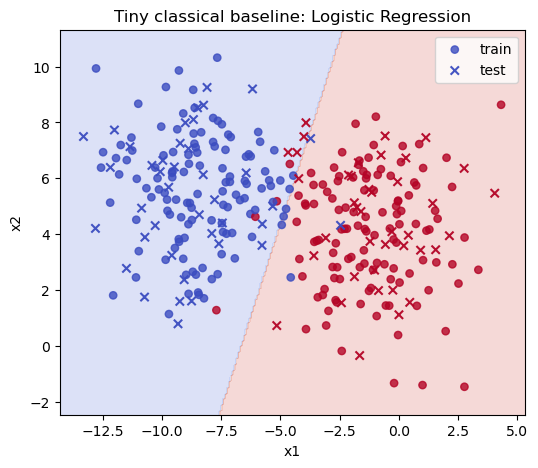

In [2]:
# 1) Generate a toy 2D classification dataset
X, y = make_blobs(n_samples=320, centers=2, cluster_std=2.1, random_state=7)

# 2) Split before any preprocessing (prevents data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)

# 3) Scale using train statistics only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4) Train a simple baseline model
clf = LogisticRegression(max_iter=1000, random_state=7)
clf.fit(X_train_scaled, y_train)

# 5) Evaluate
y_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.3f}")
print(f"F1 score: {f1:.3f}")

# 6) Visualize data and decision regions in original feature space
x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)
zz = clf.predict(grid_scaled).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, zz, alpha=0.20, cmap="coolwarm")
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", s=28, alpha=0.80, label="train")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="coolwarm", s=36, marker="x", alpha=0.95, label="test")
plt.title("Tiny classical baseline: Logistic Regression")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

### What happened in the example above?

The code followed this complete baseline workflow:
1. Generate synthetic 2D data with [`make_blobs`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html).
2. Split data with [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).
3. Fit and apply feature scaling with [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) (fit only on train to avoid [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage)).
4. Train a classifier with [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).
5. Evaluate with [`accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) and [`f1_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html).
6. Visualize decision regions and samples using `matplotlib`.

### Task 1 (coding): Nonlinear variant of the same pipeline

Build a second baseline inspired by the example above, but now use a **nonlinear** dataset and compare two models.

- Generate data with [`make_moons`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html): `make_moons(n_samples=400, noise=0.25, random_state=11)`.
- Keep the same leakage-safe pipeline: split first with [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), then fit [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) only on train.
- Train and compare:
   - [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
   - [`SVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) with `kernel="rbf"`
- Report test [`accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) and [`f1_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html) for both models.
- Plot decision regions for both models side by side.
- Write 2-3 lines: which model is more suitable here, and why?

<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 1 solution:</b> <a href="01-what-is-ml-and-what-is-qml-solutions.ipynb#task1-solution">Click here for Task 1 solution</a>
</div>

In [3]:
# Task 1 starter
from sklearn.datasets import make_moons
from sklearn.svm import SVC

# TODO: generate nonlinear data with make_moons
# TODO: split and scale (fit scaler on train only)
# TODO: train LogisticRegression and SVC(kernel='rbf')
# TODO: report test Accuracy and F1 for both models
# TODO: plot decision regions side by side
# TODO: short conclusion (2-3 lines)

## What is QML?

Quantum machine learning (QML) is the intersection of machine learning and quantum computing. The learning objective is still classical (classification, regression, clustering, or generation), but at least one core computation is quantum. For classical data, a common pattern is: encode $\vec{x}$ into a quantum state (for example with a feature map $U_F(\vec{x})$), process it with a quantum model or kernel, and measure to obtain classical outputs used for training and evaluation.

In current hardware conditions (NISQ era), most practical QML methods are **hybrid quantum-classical**: a classical optimizer updates parameters, while a quantum backend (simulator or device) evaluates circuits/kernels many times. So QML does not replace ML fundamentals; it extends the ML pipeline with quantum components.

Common QML families include:
- Quantum kernels and similarity-based methods.
- Variational quantum models (trainable parametrized circuits).
- Quantum generative models.
- Quantum-neural-network-style architectures.

Why QML is interesting:
- It can naturally model quantum data.
- It can induce rich representations through superposition and entanglement.
- It can introduce new inductive biases for specific tasks.

Practical caveat: QML is promising, but advantage is not guaranteed. Performance must be validated with fair protocols and strong classical references.

<p align="center">
  <img style="display:block; margin-left: auto; margin-right: auto;" src="./images/qml-at-a-glance.png" alt="QML at a glance" width="800"/>
</p>

This diagram summarizes the minimum idea of QML: classical task, quantum core computation, and hybrid training/evaluation loop. Here, $U_A(\boldsymbol{\theta})$ denotes a generic trainable quantum block; concrete architectures will be introduced in later sections.

## When is QML a good candidate?

QML is usually a good candidate when there is a **clear technical reason** to expect value from quantum representations, not only curiosity. A practical go/no-go checklist is:

- **Data and structure fit**: the problem involves quantum-native data, or there is a plausible mapping from classical data to a useful quantum feature space.
- **Modeling hypothesis**: you can state why a quantum kernel/ansatz might capture structure that simple classical models miss.
- **Resource feasibility**: qubit count, circuit depth, number of shots, and total runtime are realistic for your simulator/device budget.
- **Hybrid training viability**: optimization is stable enough to run repeatedly (for example, no severe gradient collapse or extreme variance across random seeds).
- **Evaluation rigor**: same data splits, same metrics, and comparable tuning effort for classical and quantum models.
- **Cost-benefit relevance**: expected metric gains justify extra complexity.

Warning signs that QML may be a weak choice:
- For classical-data tasks, no strong classical baseline is established.
- Claimed gains appear only on tiny toy settings with high quantum overhead.
- Protocols are not comparable (different preprocessing, different budgets, or data leakage).

Practical rule: start classical-first for classical-data tasks; move to QML when you have a concrete quantum hypothesis and can test it under fair, reproducible evaluation.

### Task 2 (reflection): Fair comparison checklist
Pick one toy problem and write a short checklist with:
1. One reasonable baseline (classical for classical data, or a quantum-native reference when applicable).
2. One metric and one validation protocol.
3. One concrete reason QML might help on that problem.
4. Two risks of unfair comparison and how you would mitigate them.

<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 2 solution:</b> <a href="01-what-is-ml-and-what-is-qml-solutions.ipynb#task2-solution">Click here for Task 2 solution</a>
</div>